# Kiểm thử End-to-End: Sinh Text bằng LLaVA và Dự đoán bằng MulCo trên tập PlantVillage Small
Tập dữ liệu: `data/PlantVillage_test_overlap_small` (11 classes).
Sử dụng Mapping cố định từ 28 classes của PlantDoc để đảm bảo không bị lệch index.

In [1]:
import os
import sys
import time
from pathlib import Path
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from transformers import CLIPTokenizer, CLIPModel, AutoProcessor, LlavaForConditionalGeneration, BitsAndBytesConfig
from tqdm.notebook import tqdm
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Tự động tìm thư mục gốc (chứa src)
current_dir = Path.cwd()
PROJECT_ROOT = current_dir
while not (PROJECT_ROOT / 'src').exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))
print(f"Project Root: {PROJECT_ROOT}")

from src.models.backbones.vision.convnext_cbam import ConvNeXt_CBAM
from src.models.fusion.mulco_fusion import MulCoFusionBlock
from src.models.multimodal.mulco_classifier import Conv1x1Classifier

Project Root: /media/data3/users/luongdth/MulCo-PlantNet


## 1. Định nghĩa Dataset với Mapping Index cố định

In [2]:
import json

# Sử dụng mapping index TỪ FILE JSON GỐC thay vì alphabet
PLANTDOC_CLASS_MAP = {'Apple_Scab_Leaf': 2, 'Apple_leaf': 0, 'Apple_rust_leaf': 1, 'Bell_pepper_leaf': 3, 'Bell_pepper_leaf_spot': 4, 'Blueberry_leaf': 5, 'Cherry_leaf': 6, 'Corn_Gray_leaf_spot': 7, 'Corn_leaf_blight': 8, 'Corn_rust_leaf': 9, 'Peach_leaf': 12, 'Potato_leaf_early_blight': 13, 'Potato_leaf_late_blight': 14, 'Raspberry_leaf': 15, 'Soyabean_leaf': 16, 'Squash_Powdery_mildew_leaf': 17, 'Strawberry_leaf': 18, 'Tomato_Early_blight_leaf': 19, 'Tomato_Septoria_leaf_spot': 26, 'Tomato_leaf': 20, 'Tomato_leaf_bacterial_spot': 21, 'Tomato_leaf_late_blight': 22, 'Tomato_leaf_mosaic_virus': 23, 'Tomato_leaf_yellow_virus': 24, 'Tomato_mold_leaf': 25, 'Tomato_two_spotted_spider_mites_leaf': 27, 'grape_leaf': 10, 'grape_leaf_black_rot': 11}

print("Using TRUE PLANTDOC_CLASS_MAP from JSON Labels:")
for k, v in sorted(PLANTDOC_CLASS_MAP.items(), key=lambda x: x[1]):
    print(f"  '{k}': {v},")

class SimpleImageDataset(Dataset):
    def __init__(self, image_root):
        self.image_root = Path(image_root)
        self.classes = sorted([d.name for d in self.image_root.iterdir() if d.is_dir()])
        
        self.samples = []
        for cls_name in self.classes:
            cls_dir = self.image_root / cls_name
            true_label = PLANTDOC_CLASS_MAP.get(cls_name, -1)
            if true_label == -1:
                print(f"Cảnh báo: Class {cls_name} không có trong mapping!")
            for img_path in cls_dir.glob("*.*"): 
                if img_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
                    self.samples.append({
                        "image_path": str(img_path),
                        "class_name": cls_name,
                        "label": true_label
                    })
                    
    def __len__(self):
        return len(self.samples)
        
    def __getitem__(self, idx):
        return self.samples[idx]

data_path = os.path.join(PROJECT_ROOT, "data", "PlantVillage_test_overlap_small")
test_dataset = SimpleImageDataset(data_path)
NUM_CLASSES = len(test_dataset.classes)
print(f"Tìm thấy {NUM_CLASSES} classes trong thư mục: {test_dataset.classes}")
print(f"Total items to test: {len(test_dataset)}")

Using TRUE PLANTDOC_CLASS_MAP from JSON Labels:
  'Apple_leaf': 0,
  'Apple_rust_leaf': 1,
  'Apple_Scab_Leaf': 2,
  'Bell_pepper_leaf': 3,
  'Bell_pepper_leaf_spot': 4,
  'Blueberry_leaf': 5,
  'Cherry_leaf': 6,
  'Corn_Gray_leaf_spot': 7,
  'Corn_leaf_blight': 8,
  'Corn_rust_leaf': 9,
  'grape_leaf': 10,
  'grape_leaf_black_rot': 11,
  'Peach_leaf': 12,
  'Potato_leaf_early_blight': 13,
  'Potato_leaf_late_blight': 14,
  'Raspberry_leaf': 15,
  'Soyabean_leaf': 16,
  'Squash_Powdery_mildew_leaf': 17,
  'Strawberry_leaf': 18,
  'Tomato_Early_blight_leaf': 19,
  'Tomato_leaf': 20,
  'Tomato_leaf_bacterial_spot': 21,
  'Tomato_leaf_late_blight': 22,
  'Tomato_leaf_mosaic_virus': 23,
  'Tomato_leaf_yellow_virus': 24,
  'Tomato_mold_leaf': 25,
  'Tomato_Septoria_leaf_spot': 26,
  'Tomato_two_spotted_spider_mites_leaf': 27,
Tìm thấy 11 classes trong thư mục: ['Bell_pepper_leaf_spot', 'Potato_leaf_early_blight', 'Potato_leaf_late_blight', 'Tomato_Early_blight_leaf', 'Tomato_Septoria_leaf_s

## 2. Cấu hình & Định nghĩa Model MulCo

In [3]:
class MulCoEndToEnd(nn.Module):
    def __init__(self, num_classes=28, proj_dim=512, spatial_size=(7, 7)):
        super().__init__()
        self.image_backbone = ConvNeXt_CBAM(num_classes=num_classes)
        self.text_backbone = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").text_model
        
        self.img_proj = nn.Conv2d(1024, proj_dim, kernel_size=1)
        self.txt_proj = nn.Linear(512, proj_dim)
        
        self.fusion_blocks = nn.ModuleList([
            MulCoFusionBlock(dim=proj_dim, num_heads=8) for _ in range(3)
        ])
        
        self.classifier = Conv1x1Classifier(in_channels=proj_dim, num_classes=num_classes, spatial_size=spatial_size)

    def forward(self, images, input_ids, attention_mask):
        img_feat = self.image_backbone.forward_features_spatial(images) 
        txt_out = self.text_backbone(input_ids=input_ids, attention_mask=attention_mask)
        txt_feat = txt_out.last_hidden_state
        
        img_feat = self.img_proj(img_feat)
        txt_feat = self.txt_proj(txt_feat)
        
        for block in self.fusion_blocks:
            img_feat, txt_feat = block(img_feat, txt_feat)
            
        return self.classifier(img_feat)

## 3. Load Models (LLaVA & MulCo)

In [4]:
import os
from huggingface_hub import login

# LƯU Ý: Thay 'YOUR_HF_TOKEN' bằng Access Token của bạn
HF_TOKEN = "YOUR_HF_TOKEN"

if HF_TOKEN != "YOUR_HF_TOKEN":
    login(token=HF_TOKEN)
    os.environ["HF_TOKEN"] = HF_TOKEN
    print("Đã cấu hình Hugging Face Token thành công!")
else:
    print("Vui lòng thay đổi YOUR_HF_TOKEN thành token thực tế của bạn.")


Đã cấu hình Hugging Face Token thành công!


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if 'llava_model' in globals() and 'llava_processor' in globals():
    print("LLaVA model is already loaded in memory. Skipping load.")
else:
    # Khởi tạo LLaVA
    print("Loading LLaVA-1.5-7B...")
    llava_processor = AutoProcessor.from_pretrained("llava-hf/llava-1.5-7b-hf")
    quantization_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4"
    )
    llava_model = LlavaForConditionalGeneration.from_pretrained(
        "llava-hf/llava-1.5-7b-hf",
        quantization_config=quantization_config,
        device_map="auto"
    )

Using device: cuda
Loading LLaVA-1.5-7B...


Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

In [6]:
if 'mulco_model' in globals():
    print("MulCo model is already loaded in memory. Skipping load.")
else:
    # Khởi tạo MulCo với số lượng class là 28 (theo checkpoint đã train)
    print("Loading MulCo...")
    mulco_model = MulCoEndToEnd(num_classes=28).to(device)
    
    ckpt_path = os.path.join(PROJECT_ROOT, "archive", "cross_attention_3blocks_depth_aug", "best_fine_tuned_model.pth")
    if os.path.exists(ckpt_path):
        mulco_model.load_state_dict(torch.load(ckpt_path))
        print(f"Loaded checkpoint from {ckpt_path}")
    else:
        print(f"Cảnh báo: Không tìm thấy checkpoint tại {ckpt_path}, bạn nhớ trỏ đúng file")
    mulco_model.eval()
    
    # Bộ mã hóa văn bản của CLIP và Phép biến đổi ảnh
    clip_tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")
    mulco_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

Loading MulCo...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loaded checkpoint from /media/data3/users/luongdth/MulCo-PlantNet/archive/cross_attention_3blocks_depth_aug/best_fine_tuned_model.pth


## 4. Khởi tạo Pipeline Dự Đoán End-to-End

In [7]:
import re

def normalize_caption_for_clip(text: str) -> str:
    text = (text or "").strip()
    text = text.replace("\r\n", "\n").replace("\r", "\n")

    for i in range(1, 8):
        text = re.sub(rf"(?i)\bstep\s*{i}\s*:", f"Step {i}:", text)
        text = re.sub(rf"(?i)\bstep{i}\b", f"Step {i}", text)

    text = " ".join(line.strip() for line in text.split("\n") if line.strip())
    text = re.sub(r"\s+", " ", text).strip()
    return text

def predict_end_to_end(image_path):
    raw_image = Image.open(image_path).convert("RGB")
    
    # --- Bước 1: Sinh Text từ LLaVA ---
    prompt = (
        "USER: <image>\n"
        "Act as an expert plant pathologist. Please analyze the plant leaf carefully and describe it according to the following guidelines. You MUST strictly format your response line by line, starting with 'Step 1:', 'Step 2:', etc.\n"
        "Step 1: Identify the base color of the leaf and meticulously describe any spots, lesions, or discolored areas (location, size, color).\n"
        "Step 2: Describe the overall shape of the leaf (e.g., round, oval, heart-shaped, pinnate, compound).\n"
        "Step 3: Describe the texture of the leaf surface (e.g., smooth, hairy, wrinkled).\n"
        "Step 4: Describe the characteristics of the leaf edges (e.g., smooth, serrated, wavy, lobed).\n"
        "Step 5: Describe any visible physical damages, such as holes, tears, or wilting.\n"
        "Step 6: Describe the distribution and color of the leaf veins.\n"
        "Step 7: If the petiole is visible, describe its thickness and color.\n"
        "Step 8: Highlight key microscopic disease markers: explicitly state if you see 'concentric rings' (target-like patterns in spots), 'gray/white centers' in lesions, 'yellow halos' around spots, or 'white mold'.\n"
        "Please keep the description objective but use precise botanical and pathological terms to differentiate similar diseases.\n"
        "ASSISTANT: Step 1:"
    )
    inputs = llava_processor(text=prompt, images=raw_image, return_tensors="pt").to(device, torch.float16)
    
    with torch.no_grad():
        output = llava_model.generate(**inputs, max_new_tokens=350)
    generated_text = llava_processor.decode(output[0], skip_special_tokens=True)
    
    # Cắt bỏ phần prompt để lấy đúng câu trả lời
    raw_caption = generated_text.split("ASSISTANT:")[-1].strip()
    if not raw_caption.startswith("Step 1:"):
        raw_caption = "Step 1: " + raw_caption
    
    normalized_caption = normalize_caption_for_clip(raw_caption)
    
    # --- Bước 2: Tiền xử lý cho MulCo ---
    img_tensor = mulco_transform(raw_image).unsqueeze(0).to(device)
    
    text_tokens = clip_tokenizer(
        [normalized_caption], 
        padding=True, 
        truncation=True, 
        max_length=77, 
        return_tensors="pt"
    )
    input_ids = text_tokens.input_ids.to(device)
    attn_mask = text_tokens.attention_mask.to(device)
    
    # --- Bước 3: Đưa vào MulCo dự đoán ---
    with torch.no_grad():
        logits = mulco_model(img_tensor, input_ids, attn_mask)
        pred = torch.argmax(logits, dim=1).item()
        
    torch.cuda.empty_cache()
    return pred, raw_caption

## 5. Chạy Đánh Giá Thực Tế

End-to-End Inference:   0%|          | 0/300 [00:00<?, ?it/s]


--- Image: e80de14e-9d15-4dc6-b519-6d5af14ba216___JR_B.Spot 8835.JPG | Time: 34.61s ---
Generated Caption:
Step 1: The leaf has a green base color with multiple spots and lesions. The spots are brown and have a yellow halo around them. The lesions are irregularly shaped and have a gray/white center.
Step 2: The leaf is heart-shaped with a smooth surface.
Step 3: The leaf surface is smooth.
Step 4: The leaf edges are smooth.
Step 5: There are no visible physical damages.
Step 6: The leaf veins are green.
Step 7: The petiole is visible and is thick and green.
Step 8: The leaf has concentric rings in the spots and yellow halos around them.
-> Predicted class: 4 | True class: 4

--- Image: 389480c3-0209-45e3-b3ee-2447b22de68f___JR_B.Spot 9016.JPG | Time: 8.75s ---
Generated Caption:
Step 1: The leaf has a green base color with multiple spots and lesions. The spots are brown and have a yellow halo around them. The lesions are irregularly shaped and have a gray/white center.
Step 2: The lea

/media/data3/users/luongdth/anaconda3/envs/gr1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")



End-to-End Evaluation Results (on 300 samples):
Accuracy:          0.4867
Balanced Accuracy: 0.4830

Classification Report (Precision, Recall, F1-Score):

                                      precision    recall  f1-score   support

               Bell_pepper_leaf_spot       0.93      0.93      0.93        28
            Potato_leaf_early_blight       0.46      0.79      0.58        28
             Potato_leaf_late_blight       0.44      0.82      0.57        28
            Tomato_Early_blight_leaf       0.53      0.30      0.38        27
          Tomato_leaf_bacterial_spot       0.35      0.26      0.30        27
             Tomato_leaf_late_blight       0.46      0.41      0.43        27
            Tomato_leaf_mosaic_virus       0.50      0.30      0.37        27
            Tomato_leaf_yellow_virus       0.68      0.63      0.65        27
                    Tomato_mold_leaf       0.52      0.59      0.55        27
           Tomato_Septoria_leaf_spot       0.53      0.30      

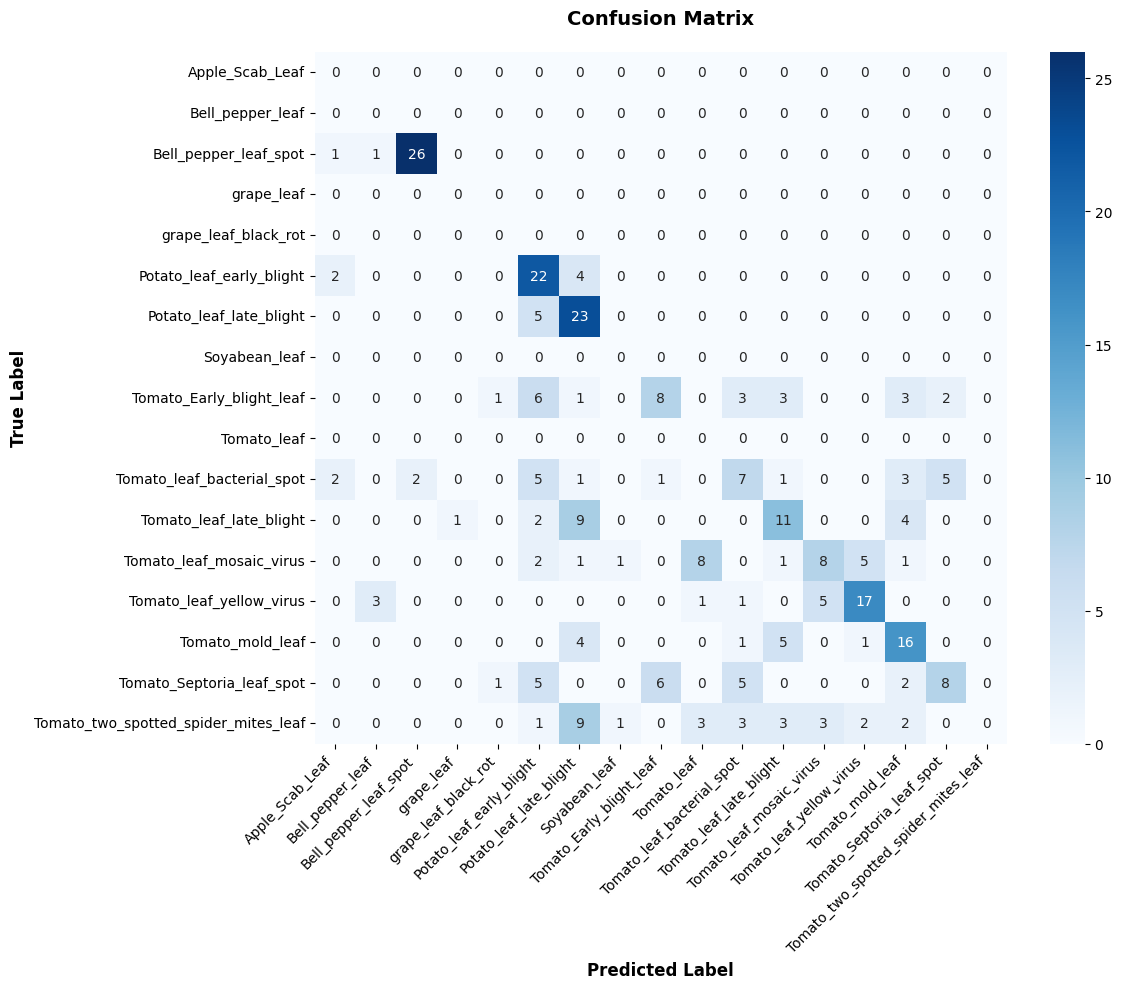

In [8]:
all_preds = []
all_labels = []

# Mẹo: Ban đầu bạn nên đặt `num_samples_to_test = 10` để chạy thử xem code chạy ổn không.
num_samples_to_test = len(test_dataset)

for idx in tqdm(range(num_samples_to_test), desc="End-to-End Inference"):
    item = test_dataset[idx]
    image_path = item["image_path"]
    true_label = item["label"]
    
    start_time = time.time()
    pred, generated_caption = predict_end_to_end(image_path)
    latency = time.time() - start_time
    
    print(f"\n--- Image: {Path(image_path).name} | Time: {latency:.2f}s ---")
    print(f"Generated Caption:\n{generated_caption}")
    print(f"-> Predicted class: {pred} | True class: {true_label}")
    
    all_preds.append(pred)
    all_labels.append(true_label)

if len(all_labels) > 0:
    acc = accuracy_score(all_labels, all_preds)
    b_acc = balanced_accuracy_score(all_labels, all_preds)
    
    print(f"\n" + "="*50)
    print(f"End-to-End Evaluation Results (on {len(all_labels)} samples):")
    print(f"Accuracy:          {acc:.4f}")
    print(f"Balanced Accuracy: {b_acc:.4f}")
    print("="*50 + "\n")
    
    # Lấy mapping từ index sang tên class
    idx_to_class = {v: k for k, v in PLANTDOC_CLASS_MAP.items()}
    
    # Báo cáo Text: Chỉ hiển thị 11 classes có thực trong tập test
    true_unique_labels = sorted(list(set(all_labels)))
    true_target_names = [idx_to_class.get(idx, f"Class {idx}") for idx in true_unique_labels]
    
    print("Classification Report (Precision, Recall, F1-Score):\n")
    print(classification_report(all_labels, all_preds, labels=true_unique_labels, target_names=true_target_names, zero_division=0))
    
    # Vẽ Confusion Matrix: Hiển thị TOÀN BỘ các classes bị đoán nhầm để dễ phân tích
    all_unique_labels = sorted(list(set(all_labels) | set(all_preds)))
    all_target_names = [idx_to_class.get(idx, f"Class {idx}") for idx in all_unique_labels]
    cm = confusion_matrix(all_labels, all_preds, labels=all_unique_labels)
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=all_target_names, yticklabels=all_target_names)
    plt.title('Confusion Matrix', pad=20, fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()